# Ensemble Weight Optimisation — Objective Function Study

This notebook evaluates **10 objective function formulations** for TPE-based ensemble weight optimisation.
Each objective steers the TPE sampler toward a different trade-off between Accuracy, Recall, Precision, F1, and AUC.
Weights are searched exclusively on the **validation set**; DS1 and DS2 are used only for final evaluation.

| ID | Formula |
|---|---|
| OBJ-01 | 0.6 × Acc + 0.4 × AUC |
| OBJ-02 | 0.5 × Acc + 0.5 × Recall |
| OBJ-03 | 0.4 × Acc + 0.4 × Recall + 0.2 × AUC |
| OBJ-04 | 0.5 × Recall + 0.5 × AUC |
| OBJ-05 | 0.4 × Acc + 0.3 × Recall + 0.3 × AUC |
| OBJ-06 | 0.5 × F1 + 0.3 × Recall + 0.2 × Acc |
| OBJ-07 | 0.4 × F1 + 0.4 × AUC + 0.2 × Recall |
| OBJ-08 | 0.6 × Recall + 0.4 × F1 |
| OBJ-09 | 0.35 × Acc + 0.35 × Recall + 0.2 × F1 + 0.1 × AUC |
| OBJ-10 | 1.0 × AUC |

**Output directory:** `D:\Tree-Structured Parzen Estimator\main\testing_variabel`


---
## 1. Dependencies

In [26]:
import subprocess, sys

for pkg in ['optuna', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy']:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )
print('All packages verified.')

All packages verified.


## 2. Imports

In [27]:
import json
import warnings
import random
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

plt.rcParams.update({
    'font.family'     : 'serif',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
})

print('Imports ready.')

Imports ready.


## 3. Configuration

In [28]:
BASE_DIR = Path(r'D:\Tree-Structured Parzen Estimator\main')

RESULTS = {
    'densenet121' : BASE_DIR / 'densenet121' / 'full_pipeline_results',
    'inception_v3': BASE_DIR / 'inceptionv3' / 'full_pipeline_results',
    'xception'    : BASE_DIR / 'xception'    / 'full_pipeline_results',
    'vit_scratch' : BASE_DIR / 'vit'         / 'full_pipeline_results',
}

OUTPUT_DIR = BASE_DIR / 'testing_variabel'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_KEYS = ['densenet121', 'inception_v3', 'xception', 'vit_scratch']
MODEL_LABELS = {
    'densenet121' : 'DenseNet-121',
    'inception_v3': 'InceptionV3',
    'xception'    : 'Xception',
    'vit_scratch' : 'ViT-Pretrained',
}

# 10 objective formulations — each with a unique seed to ensure independent TPE exploration
# OBJ-10 replaces the previous precision-weighted formulation with a full AUC objective
OBJECTIVES = {
    'OBJ-01': {
        'label'  : '0.6 x Acc + 0.4 x AUC',
        'weights': {'acc': 0.6, 'auc': 0.4},
        'seed'   : 42, 'trials': 100,
    },
    'OBJ-02': {
        'label'  : '0.5 x Acc + 0.5 x Recall',
        'weights': {'acc': 0.5, 'recall': 0.5},
        'seed'   : 43, 'trials': 120,
    },
    'OBJ-03': {
        'label'  : '0.4 x Acc + 0.4 x Recall + 0.2 x AUC',
        'weights': {'acc': 0.4, 'recall': 0.4, 'auc': 0.2},
        'seed'   : 44, 'trials': 120,
    },
    'OBJ-04': {
        'label'  : '0.5 x Recall + 0.5 x AUC',
        'weights': {'recall': 0.5, 'auc': 0.5},
        'seed'   : 45, 'trials': 120,
    },
    'OBJ-05': {
        'label'  : '0.4 x Acc + 0.3 x Recall + 0.3 x AUC',
        'weights': {'acc': 0.4, 'recall': 0.3, 'auc': 0.3},
        'seed'   : 46, 'trials': 120,
    },
    'OBJ-06': {
        'label'  : '0.5 x F1 + 0.3 x Recall + 0.2 x Acc',
        'weights': {'f1': 0.5, 'recall': 0.3, 'acc': 0.2},
        'seed'   : 47, 'trials': 120,
    },
    'OBJ-07': {
        'label'  : '0.4 x F1 + 0.4 x AUC + 0.2 x Recall',
        'weights': {'f1': 0.4, 'auc': 0.4, 'recall': 0.2},
        'seed'   : 48, 'trials': 120,
    },
    'OBJ-08': {
        'label'  : '0.6 x Recall + 0.4 x F1',
        'weights': {'recall': 0.6, 'f1': 0.4},
        'seed'   : 49, 'trials': 120,
    },
    'OBJ-09': {
        'label'  : '0.35 x Acc + 0.35 x Recall + 0.2 x F1 + 0.1 x AUC',
        'weights': {'acc': 0.35, 'recall': 0.35, 'f1': 0.2, 'auc': 0.1},
        'seed'   : 50, 'trials': 150,
    },
    'OBJ-10': {
        'label'  : '1.0 x AUC',
        'weights': {'auc': 1.0},
        'seed'   : 51, 'trials': 150,
    },
}

print('Configuration loaded.')
print(f'  BASE_DIR   : {BASE_DIR}')
print(f'  OUTPUT_DIR : {OUTPUT_DIR}')
print()
print(f'  {"ID":<8} {"Trials":>7}  Formula')
print('  ' + '-' * 65)
for obj_id, cfg in OBJECTIVES.items():
    print(f'  {obj_id:<8} {cfg["trials"]:>7}  {cfg["label"]}')
print()
all_ok = True
for arch, path in RESULTS.items():
    ok = path.exists()
    if not ok:
        all_ok = False
    print(f'  {MODEL_LABELS[arch]:<16} [{"OK" if ok else "NOT FOUND"}]  {path}')
print()
print('All result directories found.' if all_ok else 'WARNING: one or more directories missing.')


Configuration loaded.
  BASE_DIR   : D:\Tree-Structured Parzen Estimator\main
  OUTPUT_DIR : D:\Tree-Structured Parzen Estimator\main\testing_variabel

  ID        Trials  Formula
  -----------------------------------------------------------------
  OBJ-01       100  0.6 x Acc + 0.4 x AUC
  OBJ-02       120  0.5 x Acc + 0.5 x Recall
  OBJ-03       120  0.4 x Acc + 0.4 x Recall + 0.2 x AUC
  OBJ-04       120  0.5 x Recall + 0.5 x AUC
  OBJ-05       120  0.4 x Acc + 0.3 x Recall + 0.3 x AUC
  OBJ-06       120  0.5 x F1 + 0.3 x Recall + 0.2 x Acc
  OBJ-07       120  0.4 x F1 + 0.4 x AUC + 0.2 x Recall
  OBJ-08       120  0.6 x Recall + 0.4 x F1
  OBJ-09       150  0.35 x Acc + 0.35 x Recall + 0.2 x F1 + 0.1 x AUC
  OBJ-10       150  1.0 x AUC

  DenseNet-121     [OK]  D:\Tree-Structured Parzen Estimator\main\densenet121\full_pipeline_results
  InceptionV3      [OK]  D:\Tree-Structured Parzen Estimator\main\inceptionv3\full_pipeline_results
  Xception         [OK]  D:\Tree-Structured Parze

## 4. Load Prediction Arrays

In [29]:
PROB_FILES = {
    'densenet121' : ('probs_ds1_densenet121.npy',  'val_probs_densenet121.npy',  'probs_ds2_densenet121.npy'),
    'inception_v3': ('probs_ds1_inception_v3.npy', 'val_probs_inception_v3.npy', 'probs_ds2_inception_v3.npy'),
    'xception'    : ('probs_ds1_xception.npy',     'val_probs_xception.npy',     'probs_ds2_xception.npy'),
    'vit_scratch' : ('probs_ds1_vit_scratch.npy',  'val_probs_vit_scratch.npy',  'probs_ds2_vit_scratch.npy'),
}

all_probs_ds1 = {}
all_val_probs = {}
all_probs_ds2 = {}

print('Loading prediction arrays...')
for arch in MODEL_KEYS:
    d = RESULTS[arch]
    f1, fv, f2 = PROB_FILES[arch]
    try:
        all_probs_ds1[arch] = np.load(d / f1)
        all_val_probs[arch] = np.load(d / fv)
        all_probs_ds2[arch] = np.load(d / f2)
        print(f'  {MODEL_LABELS[arch]:<16}  DS1={all_probs_ds1[arch].shape}  '
              f'val={all_val_probs[arch].shape}  DS2={all_probs_ds2[arch].shape}')
    except FileNotFoundError as e:
        print(f'  {MODEL_LABELS[arch]:<16}  MISSING: {e}')

ref          = RESULTS['densenet121']
ds1_labels   = np.load(ref / 'ds1_labels.npy')
ds2_labels   = np.load(ref / 'ds2_labels.npy')
val_labels   = np.load(ref / 'val_labels.npy')

print()
print(f'  DS1 labels : {ds1_labels.shape}  (n={len(ds1_labels)})')
print(f'  DS2 labels : {ds2_labels.shape}  (n={len(ds2_labels)})')
print(f'  Val labels : {val_labels.shape}  (n={len(val_labels)})')
print(f'\n{len(all_probs_ds1)}/{len(MODEL_KEYS)} models loaded.')

Loading prediction arrays...
  DenseNet-121      DS1=(2000,)  val=(1782,)  DS2=(1000,)
  InceptionV3       DS1=(2000,)  val=(1782,)  DS2=(1000,)
  Xception          DS1=(2000,)  val=(1782,)  DS2=(1000,)
  ViT-Pretrained    DS1=(2000,)  val=(1782,)  DS2=(1000,)

  DS1 labels : (2000,)  (n=2000)
  DS2 labels : (1000,)  (n=1000)
  Val labels : (1782,)  (n=1782)

4/4 models loaded.


## 5. Helper Functions

In [30]:
def compute_metrics(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    try:
        auc = roc_auc_score(labels, probs)
    except Exception:
        auc = 0.0
    return {
        'accuracy'  : float(accuracy_score(labels, preds)),
        'precision' : float(precision_score(labels, preds, zero_division=0)),
        'recall'    : float(recall_score(labels, preds, zero_division=0)),
        'f1'        : float(f1_score(labels, preds, zero_division=0)),
        'auc'       : float(auc),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }


def ensemble_probs(probs_dict, weights, keys):
    out = np.zeros_like(list(probs_dict.values())[0])
    for k, w in zip(keys, weights):
        out += w * probs_dict[k]
    return out


def make_objective(obj_weights):
    """Return an Optuna objective that maximises a weighted combination
    of accuracy, recall, precision, f1, and/or auc on the validation set."""
    def objective(trial):
        raw   = [trial.suggest_float(f'w_{k}', 0.05, 1.0) for k in MODEL_KEYS]
        w_norm = [r / sum(raw) for r in raw]
        probs = ensemble_probs(all_val_probs, w_norm, MODEL_KEYS)
        preds = (probs >= 0.5).astype(int)
        metric_vals = {
            'acc'      : accuracy_score(val_labels, preds),
            'recall'   : recall_score(val_labels, preds, zero_division=0),
            'precision': precision_score(val_labels, preds, zero_division=0),
            'f1'       : f1_score(val_labels, preds, zero_division=0),
        }
        try:
            metric_vals['auc'] = roc_auc_score(val_labels, probs)
        except Exception:
            metric_vals['auc'] = metric_vals['acc']
        return sum(obj_weights.get(m, 0.0) * metric_vals[m] for m in obj_weights)
    return objective


print('Helper functions ready.')

Helper functions ready.


## 6. TPE Search — All Objective Formulations

Each objective uses an independent TPE study with a unique seed.
Weights are searched on the validation set only; DS1 and DS2 are not seen during optimisation.

In [31]:
all_results = {}

for obj_id, cfg in OBJECTIVES.items():
    print(f'\n{"-" * 68}')
    print(f'  {obj_id}  |  {cfg["label"]}')
    print(f'  Trials: {cfg["trials"]}   Seed: {cfg["seed"]}')

    study = optuna.create_study(
        direction  = 'maximize',
        sampler    = optuna.samplers.TPESampler(
            seed                    = cfg['seed'],
            n_startup_trials        = 20,
            multivariate            = True,
            warn_independent_sampling = False,
        ),
        study_name = obj_id,
    )
    study.optimize(
        make_objective(cfg['weights']),
        n_trials          = cfg['trials'],
        show_progress_bar = True,
    )

    raw          = [study.best_params[f'w_{k}'] for k in MODEL_KEYS]
    best_weights = [r / sum(raw) for r in raw]
    weights_dict = {k: float(w) for k, w in zip(MODEL_KEYS, best_weights)}

    # Evaluate on DS1 and DS2
    ep_ds1 = ensemble_probs(all_probs_ds1, best_weights, MODEL_KEYS)
    ep_ds2 = ensemble_probs(all_probs_ds2, best_weights, MODEL_KEYS)
    m_ds1  = compute_metrics(ds1_labels, ep_ds1)
    m_ds2  = compute_metrics(ds2_labels, ep_ds2)

    all_results[obj_id] = {
        'label'     : cfg['label'],
        'best_score': float(study.best_value),
        'weights'   : weights_dict,
        'ds1'       : m_ds1,
        'ds2'       : m_ds2,
    }

    print(f'  Val score  : {study.best_value:.6f}')
    print(f'  DS1        : Acc={m_ds1["accuracy"]:.4f}  Recall={m_ds1["recall"]:.4f}  '
          f'Prec={m_ds1["precision"]:.4f}  F1={m_ds1["f1"]:.4f}  AUC={m_ds1["auc"]:.6f}')
    print(f'  DS2        : Acc={m_ds2["accuracy"]:.4f}  Recall={m_ds2["recall"]:.4f}  '
          f'Prec={m_ds2["precision"]:.4f}  F1={m_ds2["f1"]:.4f}  AUC={m_ds2["auc"]:.6f}')
    print(f'  Weights    : DenseNet={weights_dict["densenet121"]:.3f}  '
          f'InceptionV3={weights_dict["inception_v3"]:.3f}  '
          f'Xception={weights_dict["xception"]:.3f}  '
          f'ViT={weights_dict["vit_scratch"]:.3f}')

    # Save per-objective weights
    obj_dir = OUTPUT_DIR / obj_id
    obj_dir.mkdir(parents=True, exist_ok=True)
    with open(obj_dir / 'weights.json', 'w') as fh:
        json.dump(weights_dict, fh, indent=2)

print(f'\n{"=" * 68}')
print('All 10 objectives completed.')


--------------------------------------------------------------------
  OBJ-01  |  0.6 x Acc + 0.4 x AUC
  Trials: 100   Seed: 42


  0%|          | 0/100 [00:00<?, ?it/s]

  Val score  : 0.956524
  DS1        : Acc=0.9620  Recall=0.9550  Prec=0.9686  F1=0.9617  AUC=0.994203
  DS2        : Acc=0.9740  Recall=0.9700  Prec=0.9778  F1=0.9739  AUC=0.996580
  Weights    : DenseNet=0.247  InceptionV3=0.179  Xception=0.121  ViT=0.452

--------------------------------------------------------------------
  OBJ-02  |  0.5 x Acc + 0.5 x Recall
  Trials: 120   Seed: 43


  0%|          | 0/120 [00:00<?, ?it/s]

  Val score  : 0.932713
  DS1        : Acc=0.9620  Recall=0.9580  Prec=0.9657  F1=0.9618  AUC=0.994288
  DS2        : Acc=0.9750  Recall=0.9720  Prec=0.9779  F1=0.9749  AUC=0.996572
  Weights    : DenseNet=0.246  InceptionV3=0.269  Xception=0.180  ViT=0.306

--------------------------------------------------------------------
  OBJ-03  |  0.4 x Acc + 0.4 x Recall + 0.2 x AUC
  Trials: 120   Seed: 44


...

  Val score  : 0.930865
  DS1        : Acc=0.9615  Recall=0.9570  Prec=0.9657  F1=0.9613  AUC=0.994036
  DS2        : Acc=0.9740  Recall=0.9700  Prec=0.9778  F1=0.9739  AUC=0.996084
  Weights    : DenseNet=0.240  InceptionV3=0.201  Xception=0.252  ViT=0.307

--------------------------------------------------------------------
  OBJ-09  |  0.35 x Acc + 0.35 x Recall + 0.2 x F1 + 0.1 x AUC
  Trials: 150   Seed: 50


  0%|          | 0/150 [00:00<?, ?it/s]

  Val score  : 0.939447
  DS1        : Acc=0.9620  Recall=0.9580  Prec=0.9657  F1=0.9618  AUC=0.994058
  DS2        : Acc=0.9740  Recall=0.9700  Prec=0.9778  F1=0.9739  AUC=0.996092
  Weights    : DenseNet=0.226  InceptionV3=0.204  Xception=0.255  ViT=0.315

--------------------------------------------------------------------
  OBJ-10  |  1.0 x AUC
  Trials: 150   Seed: 51


  0%|          | 0/150 [00:00<?, ?it/s]

  Val score  : 0.983057
  DS1        : Acc=0.9615  Recall=0.9470  Prec=0.9753  F1=0.9609  AUC=0.993890
  DS2        : Acc=0.9750  Recall=0.9700  Prec=0.9798  F1=0.9749  AUC=0.997124
  Weights    : DenseNet=0.040  InceptionV3=0.339  Xception=0.093  ViT=0.529

All 10 objectives completed.


## 7. Results Table

In [32]:
rows = []
for obj_id, res in all_results.items():
    d1, d2 = res['ds1'], res['ds2']
    rows.append({
        'ID'            : obj_id,
        'Formula'       : res['label'],
        'DS1 Accuracy'  : round(d1['accuracy'],  4),
        'DS1 Recall'    : round(d1['recall'],    4),
        'DS1 Precision' : round(d1['precision'], 4),
        'DS1 F1'        : round(d1['f1'],        4),
        'DS1 AUC'       : round(d1['auc'],       4),
        'DS2 Accuracy'  : round(d2['accuracy'],  4),
        'DS2 Recall'    : round(d2['recall'],    4),
        'DS2 F1'        : round(d2['f1'],        4),
        'DS2 AUC'       : round(d2['auc'],       4),
    })

df = pd.DataFrame(rows).set_index('ID')

print('=' * 110)
print('  Objective Function Comparison — DS1 Test Set + DS2 Cross-Dataset Evaluation')
print('=' * 110)
display(df)

df.to_csv(OUTPUT_DIR / 'objective_comparison.csv')
print(f'\nSaved: objective_comparison.csv')

print()
print('Best objective per metric (DS1):')
for col in ['DS1 Accuracy', 'DS1 Recall', 'DS1 F1', 'DS1 AUC']:
    idx = df[col].idxmax()
    print(f'  {col:<16}  {idx}  ({df.loc[idx, col]:.4f})  —  {all_results[idx]["label"]}')

print()
print('Best objective per metric (DS2):')
for col in ['DS2 Accuracy', 'DS2 Recall', 'DS2 F1', 'DS2 AUC']:
    idx = df[col].idxmax()
    print(f'  {col:<16}  {idx}  ({df.loc[idx, col]:.4f})  —  {all_results[idx]["label"]}')

  Objective Function Comparison — DS1 Test Set + DS2 Cross-Dataset Evaluation


,Formula,DS1 Accuracy,DS1 Recall,DS1 Precision,DS1 F1,DS1 AUC,DS2 Accuracy,DS2 Recall,DS2 F1,DS2 AUC
ID,,,,,,,,,,
OBJ-01,0.6 x Acc + 0.4 x AUC,0.9620,0.955,0.9686,0.9617,0.9942,0.974,0.970,0.9739,0.9966
OBJ-02,0.5 x Acc + 0.5 x Recall,0.9620,0.958,0.9657,0.9618,0.9943,0.975,0.972,0.9749,0.9966
OBJ-03,0.4 x Acc + 0.4 x Recall + 0.2 x AUC,0.9615,0.957,0.9657,0.9613,0.9941,0.974,0.970,0.9739,0.9961
OBJ-04,0.5 x Recall + 0.5 x AUC,0.9615,0.957,0.9657,0.9613,0.9941,0.974,0.970,0.9739,0.9962
OBJ-05,0.4 x Acc + 0.3 x Recall + 0.3 x AUC,0.9615,0.957,0.9657,0.9613,0.9940,0.974,0.970,0.9739,0.9961
OBJ-06,0.5 x F1 + 0.3 x Recall + 0.2 x Acc,0.9620,0.958,0.9657,0.9618,0.9941,0.974,0.970,0.9739,0.9962
OBJ-07,0.4 x F1 + 0.4 x AUC + 0.2 x Recall,0.9620,0.958,0.9657,0.9618,0.9941,0.975,0.972,0.9749,0.9964
OBJ-08,0.6 x Recall + 0.4 x F1,0.9615,0.957,0.9657,0.9613,0.9940,0.974,0.970,0.9739,0.9961
OBJ-09,0.35 x Acc + 0.35 x Recall + 0.2 x F1 + 0.1 x AUC,0.9620,0.958,0.9657,0.9618,0.9941,0.974,0.970,0.9739,0.9961



Saved: objective_comparison.csv

Best objective per metric (DS1):
  DS1 Accuracy      OBJ-01  (0.9620)  —  0.6 x Acc + 0.4 x AUC
  DS1 Recall        OBJ-02  (0.9580)  —  0.5 x Acc + 0.5 x Recall
  DS1 F1            OBJ-02  (0.9618)  —  0.5 x Acc + 0.5 x Recall
  DS1 AUC           OBJ-02  (0.9943)  —  0.5 x Acc + 0.5 x Recall

Best objective per metric (DS2):
  DS2 Accuracy      OBJ-02  (0.9750)  —  0.5 x Acc + 0.5 x Recall
  DS2 Recall        OBJ-02  (0.9720)  —  0.5 x Acc + 0.5 x Recall
  DS2 F1            OBJ-02  (0.9749)  —  0.5 x Acc + 0.5 x Recall
  DS2 AUC           OBJ-10  (0.9971)  —  1.0 x AUC


## 8. Visualisation

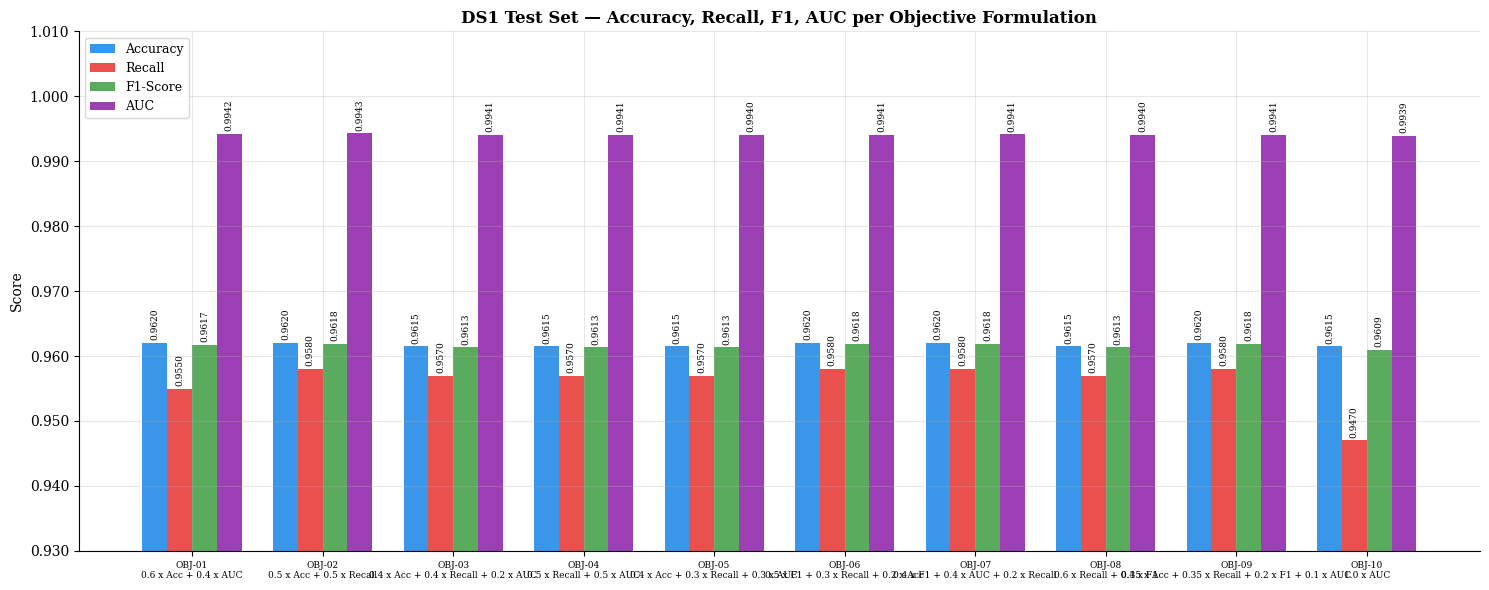

Saved: fig1_ds1_metrics.png


In [33]:
# ── Figure 1: DS1 metrics — grouped bar chart ────────────────────────────────
obj_ids    = list(all_results.keys())
short_ids  = [o.replace('OBJ-', 'OBJ\n') for o in obj_ids]
ds1_acc    = [all_results[o]['ds1']['accuracy']  for o in obj_ids]
ds1_rec    = [all_results[o]['ds1']['recall']    for o in obj_ids]
ds1_f1     = [all_results[o]['ds1']['f1']        for o in obj_ids]
ds1_auc    = [all_results[o]['ds1']['auc']       for o in obj_ids]

x = np.arange(len(obj_ids))
w = 0.19

fig, ax = plt.subplots(figsize=(15, 6))
b1 = ax.bar(x - 1.5*w, ds1_acc, w, label='Accuracy',  color='#1E88E5', alpha=0.88)
b2 = ax.bar(x - 0.5*w, ds1_rec, w, label='Recall',    color='#E53935', alpha=0.88)
b3 = ax.bar(x + 0.5*w, ds1_f1,  w, label='F1-Score',  color='#43A047', alpha=0.88)
b4 = ax.bar(x + 1.5*w, ds1_auc, w, label='AUC',       color='#8E24AA', alpha=0.88)

for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt='%.4f', fontsize=6.5, padding=2, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{sid}\n{all_results[o]["label"]}' for sid, o in zip([i.replace("OBJ-","OBJ-") for i in obj_ids], obj_ids)],
    fontsize=6.5,
)
ax.set_ylim([0.93, 1.01])
ax.set_ylabel('Score')
ax.set_title('DS1 Test Set — Accuracy, Recall, F1, AUC per Objective Formulation',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_ds1_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_ds1_metrics.png')

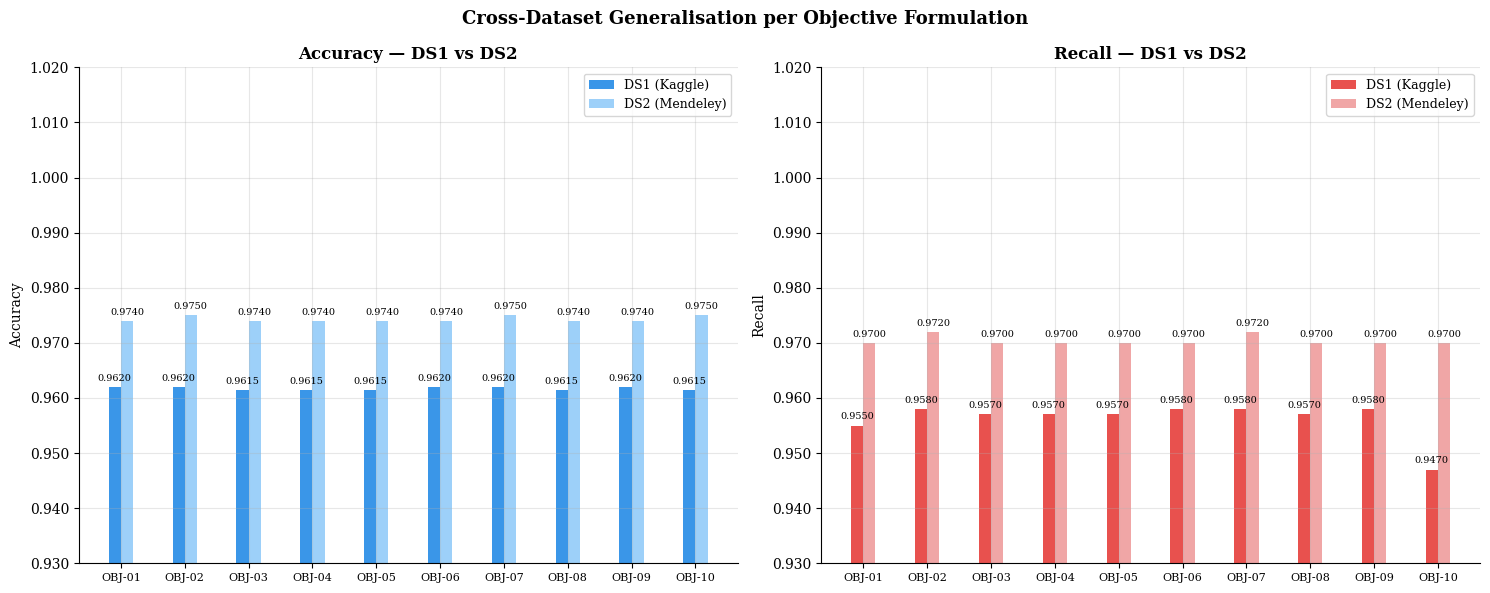

Saved: fig2_ds1_vs_ds2.png


In [34]:
# ── Figure 2: DS1 vs DS2 — Accuracy and Recall ───────────────────────────────
ds2_acc = [all_results[o]['ds2']['accuracy'] for o in obj_ids]
ds2_rec = [all_results[o]['ds2']['recall']   for o in obj_ids]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, ds1_vals, ds2_vals, ylabel, title, c1, c2 in [
    (axes[0], ds1_acc, ds2_acc, 'Accuracy',
     'Accuracy — DS1 vs DS2',   '#1E88E5', '#90CAF9'),
    (axes[1], ds1_rec, ds2_rec, 'Recall',
     'Recall — DS1 vs DS2',     '#E53935', '#EF9A9A'),
]:
    b1 = ax.bar(x - w/2, ds1_vals, w, label='DS1 (Kaggle)',   color=c1, alpha=0.88)
    b2 = ax.bar(x + w/2, ds2_vals, w, label='DS2 (Mendeley)', color=c2, alpha=0.88)
    for bars in [b1, b2]:
        ax.bar_label(bars, fmt='%.4f', fontsize=7, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(obj_ids, fontsize=8)
    ax.set_ylim([0.93, 1.02])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.suptitle('Cross-Dataset Generalisation per Objective Formulation',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_ds1_vs_ds2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_ds1_vs_ds2.png')

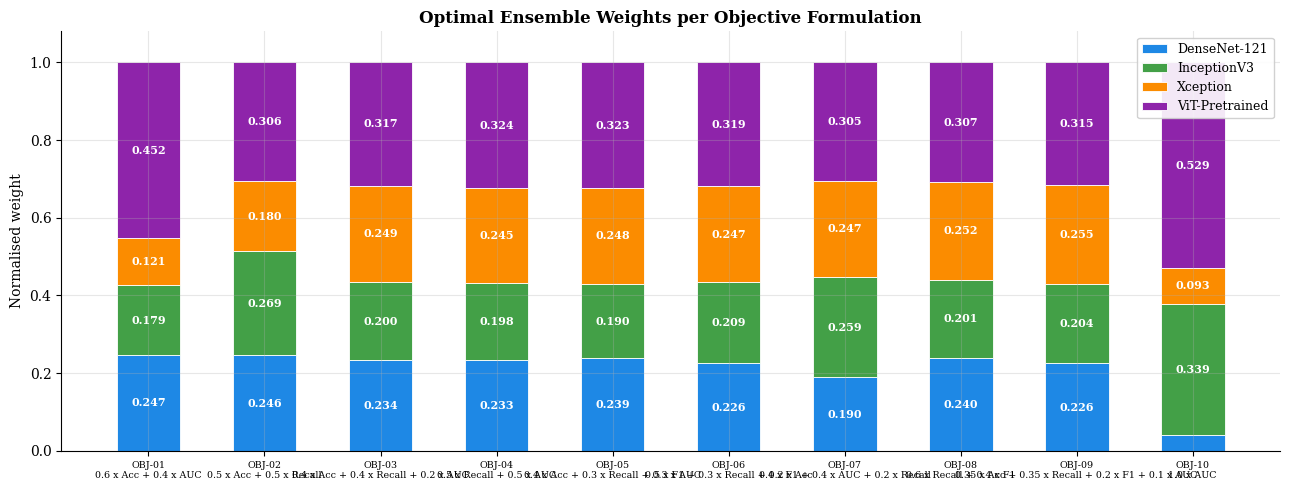

Saved: fig3_ensemble_weights.png


In [35]:
# ── Figure 3: Ensemble weights per objective — stacked bar ───────────────────
MODEL_COLORS = ['#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

fig, ax = plt.subplots(figsize=(13, 5))
bottoms = np.zeros(len(obj_ids))

for i, arch in enumerate(MODEL_KEYS):
    wvals = np.array([all_results[o]['weights'][arch] for o in obj_ids])
    bars  = ax.bar(x, wvals, bottom=bottoms,
                   color=MODEL_COLORS[i], label=MODEL_LABELS[arch],
                   edgecolor='white', linewidth=0.6, width=0.55)
    for bar, val in zip(bars, wvals):
        if val > 0.06:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold',
            )
    bottoms += wvals

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{o}\n{all_results[o]["label"]}' for o in obj_ids],
    fontsize=6.8,
)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Normalised weight')
ax.set_title('Optimal Ensemble Weights per Objective Formulation',
             fontweight='bold', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_ensemble_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_ensemble_weights.png')

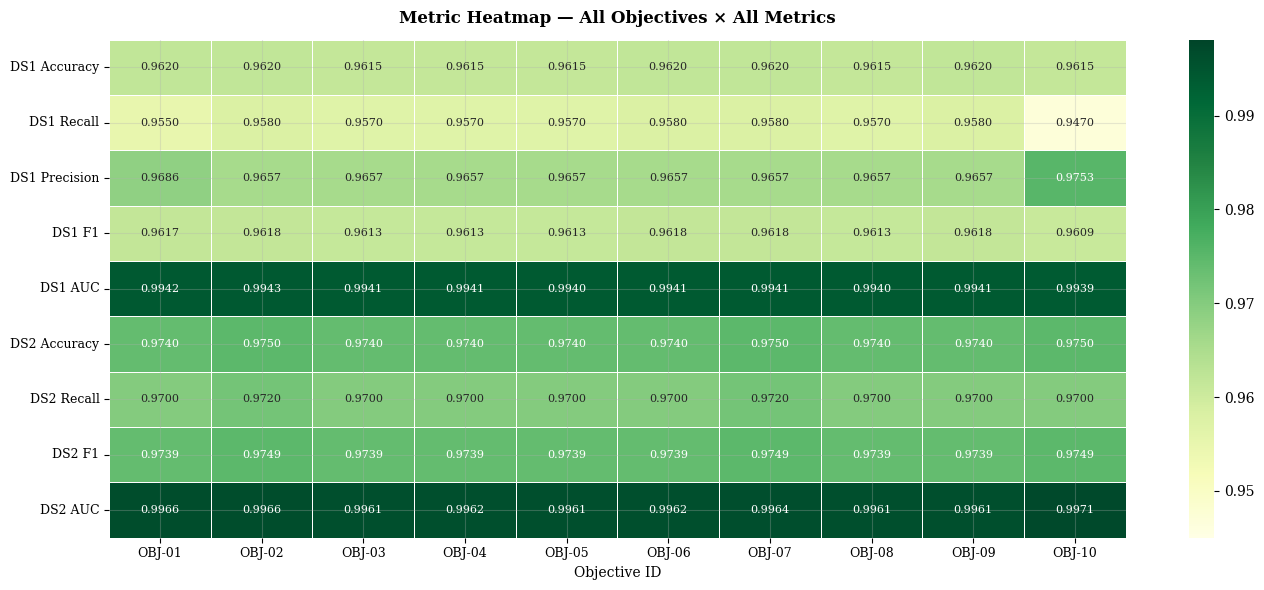

Saved: fig4_heatmap.png


In [36]:
# ── Figure 4: Heatmap — all metrics across all objectives ────────────────────
heatmap_cols = [
    'DS1 Accuracy', 'DS1 Recall', 'DS1 Precision', 'DS1 F1', 'DS1 AUC',
    'DS2 Accuracy', 'DS2 Recall', 'DS2 F1', 'DS2 AUC',
]
heatmap_data = df[heatmap_cols].T

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.4f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    vmin=heatmap_data.values.min() - 0.002,
    vmax=heatmap_data.values.max() + 0.001,
    ax=ax,
    annot_kws={'size': 8},
)
ax.set_title('Metric Heatmap — All Objectives × All Metrics',
             fontweight='bold', fontsize=12, pad=12)
ax.set_xlabel('Objective ID')
ax.set_ylabel('')
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_heatmap.png')

## 9. Save Results

In [37]:
save_data = {}
for obj_id, res in all_results.items():
    save_data[obj_id] = {
        'label'     : res['label'],
        'best_score': res['best_score'],
        'weights'   : res['weights'],
        'ds1'       : {k: v for k, v in res['ds1'].items() if k != 'conf_mat'},
        'ds2'       : {k: v for k, v in res['ds2'].items() if k != 'conf_mat'},
    }

with open(OUTPUT_DIR / 'all_objectives.json', 'w') as fh:
    json.dump(save_data, fh, indent=2)

print('Saved: all_objectives.json')
print(f'\nAll outputs written to: {OUTPUT_DIR}')
print()
for fp in sorted(OUTPUT_DIR.iterdir()):
    if fp.is_file():
        print(f'  {fp.name}')
    elif fp.is_dir():
        print(f'  {fp.name}/')

Saved: all_objectives.json

All outputs written to: D:\Tree-Structured Parzen Estimator\main\testing_variabel

  all_objectives.json
  fig1_ds1_metrics.png
  fig2_ds1_vs_ds2.png
  fig3_ensemble_weights.png
  fig4_heatmap.png
  OBJ-01/
  OBJ-02/
  OBJ-03/
  OBJ-04/
  OBJ-05/
  OBJ-06/
  OBJ-07/
  OBJ-08/
  OBJ-09/
  OBJ-10/
  objective_comparison.csv
  Testing_Variabel_Ensemble.ipynb
